# Algorithms for massive datasets project

## 1) Data loading

In [30]:
import os
import zipfile
import sys
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable
os.environ['KAGGLE_USERNAME'] = "xxxx"
os.environ['KAGGLE_KEY'] = "xxxx"
!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
with zipfile.ZipFile("imdb-dataset-of-top-1000-movies-and-tv-shows.zip", "r") as zip_ref:
    zip_ref.extractall("imdb_data")

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
imdb-dataset-of-top-1000-movies-and-tv-shows.zip: Skipping, found more recently modified local copy (use --force to force download)


In [31]:
import pandas as pd
from pyspark.sql import SparkSession
from pyspark import StorageLevel
import math
from collections import Counter
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt

In [32]:
spark = (
    SparkSession.builder.appName("IMDB MBA").getOrCreate()
    
)
sc = spark.sparkContext

In [33]:
file_path = os.environ.get("IMDB_CSV_PATH","imdb_data/imdb_top_1000.csv")
df = spark.read.csv(file_path, header=True, inferSchema=True)
df.head(2)

[Row(Poster_Link='https://m.media-amazon.com/images/M/MV5BMDFkYTc0MGEtZmNhMC00ZDIzLWFmNTEtODM1ZmRlYWMwMWFmXkEyXkFqcGdeQXVyMTMxODk2OTU@._V1_UX67_CR0,0,67,98_AL_.jpg', Series_Title='The Shawshank Redemption', Released_Year='1994', Certificate='A', Runtime='142 min', Genre='Drama', IMDB_Rating=9.3, Overview='Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.', Meta_score='80', Director='Frank Darabont', Star1='Tim Robbins', Star2='Morgan Freeman', Star3='Bob Gunton', Star4='William Sadler', No_of_Votes='2343110', Gross='28,341,469'),
 Row(Poster_Link='https://m.media-amazon.com/images/M/MV5BM2MyNjYxNmUtYTAwNi00MTYxLWJmNWYtYzZlODY3ZTk3OTFlXkEyXkFqcGdeQXVyNzkwMjQ5NzM@._V1_UY98_CR1,0,67,98_AL_.jpg', Series_Title='The Godfather', Released_Year='1972', Certificate='A', Runtime='175 min', Genre='Crime, Drama', IMDB_Rating=9.2, Overview="An organized crime dynasty's aging patriarch transfers control of his clandestine empire to 

## 2) Basket creation

In [34]:
actors = ["Star1", "Star2", "Star3", "Star4"]
baskets = (
    df.select(actors).rdd.map(lambda row: tuple(
              sorted({str(actor).strip()
                  for actor in row
                  if actor is not None
                  and str(actor).strip() != ""
              })
          )
      )
      .filter(lambda basket: len(basket) >= 2).persist(StorageLevel.MEMORY_AND_DISK)
)
n_baskets = baskets.count()

## 3) Preprocessing

In [35]:
#setting min support and partitions
min_supp = 0.004
num_partitions = 4
glob_supp = math.ceil(min_supp * n_baskets)

In [36]:
#split baskets in partitions
baskets = baskets.repartition(num_partitions).persist(
    StorageLevel.MEMORY_AND_DISK
)

n_baskets = baskets.count()

print("Number of baskets:", n_baskets)

Number of baskets: 1000


## 4) Apriori

In [37]:
#done for candidate generation
def local_apriori_pass1(partition_iterator, support_fraction):
    baskets_list = [tuple(sorted(b)) for b in partition_iterator]
    if not baskets_list:
        return iter([])

    #SON threshold
    local_threshold = math.ceil(support_fraction * len(baskets_list))

    #count single actors
    counts = Counter()
    for b in baskets_list:
        for item in b:
            counts[(item,)] += 1
            
    frequent_k = {itemset for itemset, c in counts.items() if c >= local_threshold}
    all_frequent = set(frequent_k)

    k = 2
    while frequent_k:
        #candidates generation
        prev_freq = sorted(list(frequent_k))
        candidates = set()
        
        for i in range(len(prev_freq)):
            for j in range(i + 1, len(prev_freq)):
                i1, i2 = prev_freq[i], prev_freq[j]
                
                #join only if first k-2 elements are the same
                if i1[:-1] == i2[:-1]:
                    candidate = i1 + (i2[-1],)
                    
                    #verifying that all subsets are freq
                    valid = True
                    for sub in combinations(candidate, k - 1):
                        if sub not in frequent_k:
                            valid = False
                            break
                    if valid:
                        candidates.add(candidate)
                        
        if not candidates:
            break

        #counting candidates
        counts_k = Counter()
        for b in baskets_list:
            if len(b) >= k:
                for sub in combinations(b, k):
                    if sub in candidates:
                        counts_k[sub] += 1
                        
        frequent_k = {itemset for itemset, c in counts_k.items() if c >= local_threshold}
        all_frequent.update(frequent_k)
        k += 1

    return iter(all_frequent)

## 5) SON Algorithm

In [38]:
candidates_rdd = (
    baskets
    .mapPartitions(lambda part: local_apriori_pass1(part, min_supp))
    .distinct()
    .persist(StorageLevel.MEMORY_AND_DISK)
)

candidates_set = set(candidates_rdd.collect())
bc_candidates = sc.broadcast(candidates_set)

print(f"SON candidates: {len(candidates_set)}")

SON candidates: 13488


In [39]:
#verifying size of candidates
candidate_sizes = (
    candidates_rdd
    .map(lambda itemset: (len(itemset), 1))
    .reduceByKey(lambda x, y: x + y)
    .sortByKey()
    .collect()
)

print("Candidates by size:")

for size, count in candidate_sizes:
    print("Itemsets of size", size,":",count)

Candidates by size:
Itemsets of size 1 : 2712
Itemsets of size 2 : 5830
Itemsets of size 3 : 3955
Itemsets of size 4 : 991


In [40]:
candidates_list = candidates_rdd.collect()
candidates_set = set(candidates_list)
bc_candidates = sc.broadcast(candidates_set)

## 6) SON counting

In [41]:
def count_candidates_pass2(partition_iterator):
#counts candidates locally to avoid oom error
    candidates = bc_candidates.value
    
    #group candidates by lenght
    cands_by_len = {}
    for c in candidates:
        cands_by_len.setdefault(len(c), set()).add(c)
        
    local_counts = Counter()
    
    for b in partition_iterator:
        for length, c_set in cands_by_len.items():
            if len(b) >= length:
                for sub in combinations(b, length):
                    if sub in c_set:
                        local_counts[sub] += 1
                        
    #one row for candidate for partition
    return local_counts.items()

## 7) Filtering by frequent items

In [42]:
frequent_itemsets_rdd = (
    baskets.mapPartitions(count_candidates_pass2).reduceByKey(lambda count1, count2: count1 + count2)
    .filter(lambda kv: kv[1] >= glob_supp).persist(StorageLevel.MEMORY_AND_DISK)
)

pairs_and_triples = (
    frequent_itemsets_rdd
    .filter(lambda kv: len(kv[0]) >= 2).sortBy(lambda kv: kv[1], ascending=False)
    .collect()
)

## 8) Frequent itemsets

In [43]:

print(f"Global frequent itemsets ({min_supp*100}% supp): {frequent_itemsets_rdd.count()}")
print(f"Found {len(pairs_and_triples)} frequent pairs/triples")
for itemset, count in pairs_and_triples:
    if len(itemset) == 2: type = "pair"
    elif len(itemset) == 3: type = "triple"
    else: type = f"Group of {len(itemset)}"
    print(f"[{type}] {itemset} are togethere in {count} movies")

bc_candidates.unpersist()

Global frequent itemsets (0.4% supp): 148
Found 6 frequent pairs/triples
[pair] ('Daniel Radcliffe', 'Rupert Grint') are togethere in 6 movies
[pair] ('Emma Watson', 'Rupert Grint') are togethere in 5 movies
[triple] ('Daniel Radcliffe', 'Emma Watson', 'Rupert Grint') are togethere in 5 movies
[pair] ('Daniel Radcliffe', 'Emma Watson') are togethere in 5 movies
[pair] ('Tim Allen', 'Tom Hanks') are togethere in 4 movies
[pair] ('Joe Pesci', 'Robert De Niro') are togethere in 4 movies


In [44]:
for itemset, count in frequent_itemsets_rdd.take(5):
    print(f"Actors: {itemset}")
    print(f"Total support: {count}")

Actors: ('Tatsuya Nakadai',)
Total support: 6
Actors: ('Christian Bale',)
Total support: 11
Actors: ('Leonardo DiCaprio',)
Total support: 11
Actors: ('Harrison Ford',)
Total support: 8
Actors: ('Clint Eastwood',)
Total support: 12


## 9) Association rules

In [45]:
#association rules A --> B
min_confidence = 0.75

#dictionary to load frequent itemsets
freq_dict = frequent_itemsets_rdd.collectAsMap()

rules = []

for itemset, supp_AB in freq_dict.items():
    if len(itemset) >= 2:
        for r in range(1, len(itemset)):
            for A in combinations(itemset, r):
                A = tuple(sorted(A))
                B = tuple(sorted(set(itemset) - set(A)))
                
                #confidence calculation
                if A in freq_dict:
                    supp_A = freq_dict[A]
                    confidence = supp_AB / supp_A
                    
                    if confidence >= min_confidence:
                        #lift calculation
                        supp_B = freq_dict.get(B, None)
                        lift = (confidence / (supp_B / n_baskets)) if supp_B else None
                        
                        rules.append({
                            "antecedent": A,
                            "consequent": B,
                            "support_AB": supp_AB,  #movies A U B
                            "confidence": confidence,   #if there is A % there is B?
                            "lift": lift    #if >1, significant association
                        })

print(f"{len(rules)} association rules (Confidence >= {min_confidence*100}%)")
sorted_rules = sorted(rules, key=lambda x: x["confidence"], reverse=True)
for r in sorted_rules[:10]:
    print(f"Rule: {r['antecedent']} --> {r['consequent']}")
    print(f"    Confidence: {r['confidence']*100:.0f}% "
          f" Support: {r['support_AB']}"
          f" Lift: {r['lift']:.1f}"
        )

10 association rules (Confidence >= 75.0%)
Rule: ('Daniel Radcliffe',) --> ('Rupert Grint',)
    Confidence: 100%  Support: 6 Lift: 166.7
Rule: ('Rupert Grint',) --> ('Daniel Radcliffe',)
    Confidence: 100%  Support: 6 Lift: 166.7
Rule: ('Daniel Radcliffe', 'Emma Watson') --> ('Rupert Grint',)
    Confidence: 100%  Support: 5 Lift: 166.7
Rule: ('Emma Watson', 'Rupert Grint') --> ('Daniel Radcliffe',)
    Confidence: 100%  Support: 5 Lift: 166.7
Rule: ('Tim Allen',) --> ('Tom Hanks',)
    Confidence: 100%  Support: 4 Lift: 71.4
Rule: ('Rupert Grint',) --> ('Emma Watson',)
    Confidence: 83%  Support: 5 Lift: 119.0
Rule: ('Daniel Radcliffe',) --> ('Emma Watson', 'Rupert Grint')
    Confidence: 83%  Support: 5 Lift: 166.7
Rule: ('Rupert Grint',) --> ('Daniel Radcliffe', 'Emma Watson')
    Confidence: 83%  Support: 5 Lift: 166.7
Rule: ('Daniel Radcliffe', 'Rupert Grint') --> ('Emma Watson',)
    Confidence: 83%  Support: 5 Lift: 119.0
Rule: ('Daniel Radcliffe',) --> ('Emma Watson',)
   

## 10) Graph visualization

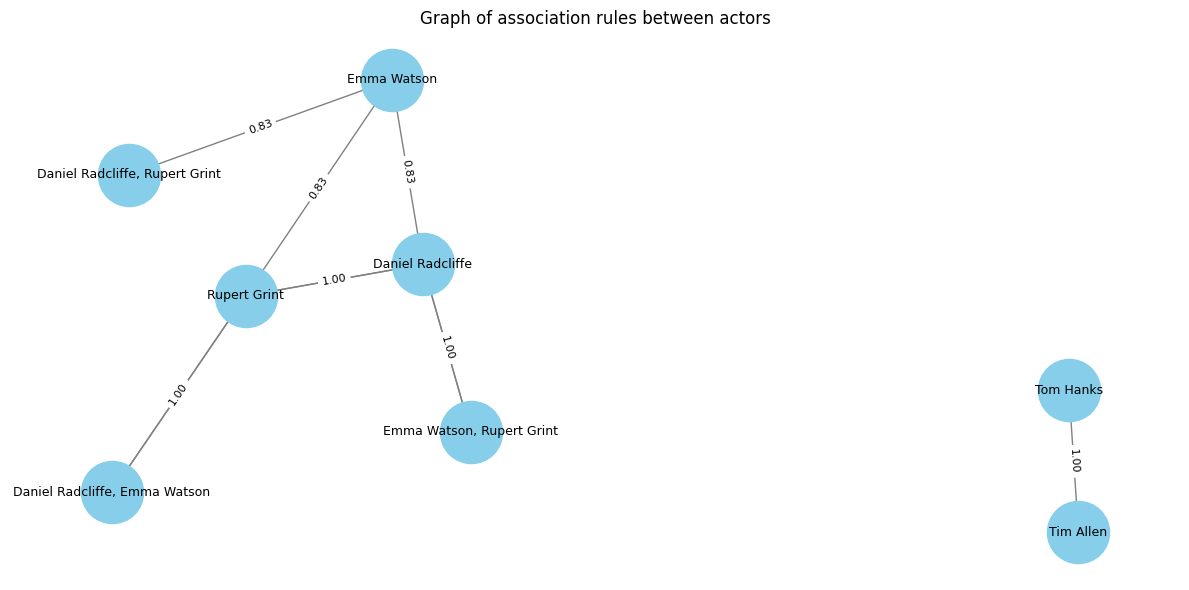

In [49]:
G = nx.DiGraph()

for r in sorted_rules[:10]:
    node_A = ", ".join(r['antecedent'])
    node_B = ", ".join(r['consequent'])
    G.add_edge(node_A, node_B, weight=r['confidence'])

plt.figure(figsize=(12, 6))
pos = nx.spring_layout(G, k=0.5, seed = 1)
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='skyblue')
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=15, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=9, font_family='sans-serif')
edge_labels = {
    (u, v): f"{d['weight']:.2f}" 
    for u, v, d in G.edges(data=True)
}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_size=8, label_pos=0.5
)

plt.title("Graph of association rules between actors")
plt.axis('off')
plt.tight_layout()
plt.show()